# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [29]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [7]:
print('Kích thước dữ liệu:', df.shape)
print('\nTên cột:', df.columns.tolist())
print('\nKiểu dữ liệu:')
display(df.dtypes.to_frame('dtype'))
print('\nThông tin tổng quát:')
df.info()

Kích thước dữ liệu: (1338, 7)

Tên cột: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Kiểu dữ liệu:


,dtype
age,int64
sex,str
bmi,float64
children,int64
smoker,str
region,str
charges,float64



Thông tin tổng quát:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## A.2. Missing values & Duplicate data

In [8]:
missing = df.isna().sum().to_frame('missing_count')
missing['missing_percent'] = (missing['missing_count'] / len(df) * 100).round(2)
print('Missing values:')
display(missing)
print('Số dòng trùng lặp:', df.duplicated().sum())

Missing values:


,missing_count,missing_percent
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


Số dòng trùng lặp: 1


## A.3. Invalid values

In [9]:
print('Giá trị duy nhất của các biến phân loại:')
for column in ['sex', 'smoker', 'region']:
    print(f'{column}: {sorted(df[column].unique())}')

invalid = pd.Series({
    'age_out_of_range': ((df['age'] < 0) | (df['age'] > 120)).sum(),
    'bmi_non_positive': (df['bmi'] <= 0).sum(),
    'children_negative': (df['children'] < 0).sum(),
    'charges_non_positive': (df['charges'] <= 0).sum(),
})
print('\nSố giá trị không hợp lệ:')
display(invalid.to_frame('count'))

Giá trị duy nhất của các biến phân loại:
sex: ['female', 'male']
smoker: ['no', 'yes']
region: ['northeast', 'northwest', 'southeast', 'southwest']

Số giá trị không hợp lệ:


,count
age_out_of_range,0
bmi_non_positive,0
children_negative,0
charges_non_positive,0


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [30]:
df['bmi_group'] = pd.cut(
    df['bmi'],
    bins=[-np.inf, 25, 30, np.inf],
    labels=['Normal', 'Overweight', 'Obese'],
    right=False
)
print('Phân bố bmi_group:')
display(df['bmi_group'].value_counts().sort_index().to_frame('count'))
df.head()

Phân bố bmi_group:


,count
bmi_group,
Normal,245
Overweight,386
Obese,707


,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [31]:
central_tendency = df[['age', 'bmi', 'children', 'charges']].agg(['mean', 'median']).T
central_tendency.columns = ['Mean', 'Median']
central_tendency['Mode'] = df[['age', 'bmi', 'children', 'charges']].mode().iloc[0]
display(central_tendency.round(2))

,Mean,Median,Mode
age,39.21,39.00,18.00
bmi,30.66,30.40,32.30
children,1.09,1.00,0.00
charges,13270.42,9382.03,1639.56


## Group 2 — Dispersion

In [32]:
dispersion = df[['age', 'bmi', 'children', 'charges']].agg(['min', 'max', 'std', 'var', 'skew']).T
dispersion['range'] = dispersion['max'] - dispersion['min']
display(dispersion[['min', 'max', 'range', 'std', 'var', 'skew']].round(2))

,min,max,range,std,var,skew
age,18.00,64.00,46.00,14.05,1.974000e+02,0.06
bmi,15.96,53.13,37.17,6.10,3.719000e+01,0.28
children,0.00,5.00,5.00,1.21,1.450000e+00,0.94
charges,1121.87,63770.43,62648.55,12110.01,1.466524e+08,1.52


## Group 3 — Location and Shape

In [33]:
location_shape = df[['age', 'bmi', 'children', 'charges']].describe(percentiles=[.25, .5, .75]).T
location_shape['IQR'] = location_shape['75%'] - location_shape['25%']
display(location_shape[['25%', '50%', '75%', 'IQR']].round(2))
print('Nhận xét: charges có mean lớn hơn median và skew dương, cho thấy phân phối lệch phải.')

,25%,50%,75%,IQR
age,27.00,39.00,51.00,24.00
bmi,26.30,30.40,34.69,8.40
children,0.00,1.00,2.00,2.00
charges,4740.29,9382.03,16639.91,11899.63


Nhận xét: charges có mean lớn hơn median và skew dương, cho thấy phân phối lệch phải.


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [34]:
smoker_summary = df.groupby('smoker', observed=True)['charges'].agg(['count', 'mean', 'median', 'std'])
smoker_summary['mean_ratio_vs_non_smoker'] = smoker_summary['mean'] / smoker_summary.loc['no', 'mean']
display(smoker_summary.round(2))

regional_smoker = df.pivot_table(index='region', columns='smoker', values='charges', aggfunc='mean', observed=True)
regional_smoker['ratio_yes_vs_no'] = regional_smoker['yes'] / regional_smoker['no']
print('So sánh theo vùng:')
display(regional_smoker.round(2))
print(f"Trung bình người hút thuốc cao {smoker_summary.loc['yes', 'mean_ratio_vs_non_smoker']:.2f} lần người không hút thuốc.")

,count,mean,median,std,mean_ratio_vs_non_smoker
smoker,,,,,
no,1064,8434.27,7345.41,5993.78,1.0
yes,274,32050.23,34456.35,11541.55,3.8


So sánh theo vùng:


smoker,no,yes,ratio_yes_vs_no
region,,,
northeast,9165.53,29673.54,3.24
northwest,8556.46,30192.00,3.53
southeast,8032.22,34845.00,4.34
southwest,8019.28,32269.06,4.02


Trung bình người hút thuốc cao 3.80 lần người không hút thuốc.


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

,pearson_corr
smoker,
no,0.084
yes,0.806


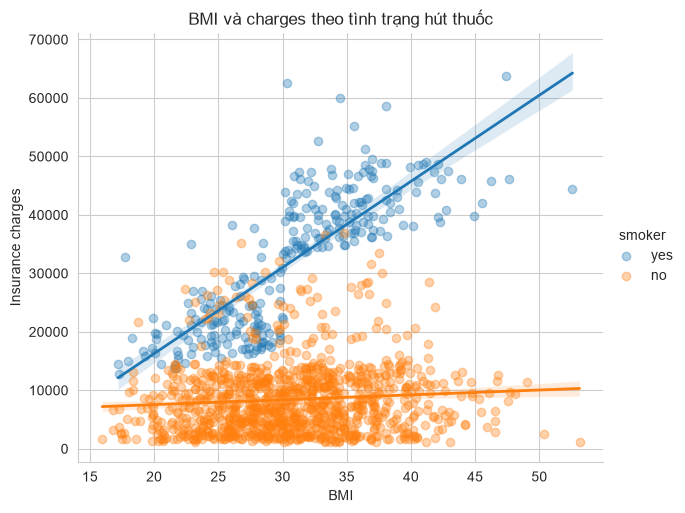

BMI tương quan mạnh hơn với charges ở nhóm smoker='yes' (r = 0.806).


In [35]:
correlation_by_smoker = df.groupby('smoker', observed=True).apply(
    lambda group: group[['bmi', 'charges']].corr().iloc[0, 1],
    include_groups=False
).rename('pearson_corr').to_frame()
display(correlation_by_smoker.round(3))

sns.lmplot(data=df, x='bmi', y='charges', hue='smoker', height=5, aspect=1.25,
           scatter_kws={'alpha': 0.35}, line_kws={'linewidth': 2})
plt.title('BMI và charges theo tình trạng hút thuốc')
plt.xlabel('BMI')
plt.ylabel('Insurance charges')
plt.show()
stronger_group = correlation_by_smoker['pearson_corr'].abs().idxmax()
print(f"BMI tương quan mạnh hơn với charges ở nhóm smoker='{stronger_group}' "
      f"(r = {correlation_by_smoker.loc[stronger_group, 'pearson_corr']:.3f}).")

## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

,count,mean,median,std
region,,,,
southeast,364,14735.41,9294.13,13971.10
northeast,324,13406.38,10057.65,11255.80
northwest,325,12417.58,8965.80,11072.28
southwest,325,12346.94,8798.59,11557.18


Vùng có chi phí trung bình cao nhất: southeast (14,735.41).


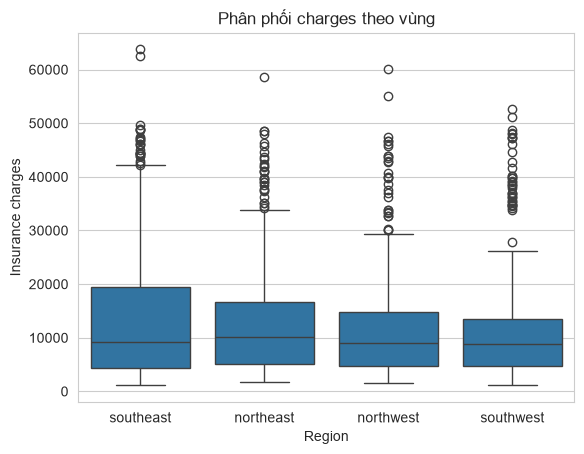

In [36]:
region_summary = df.groupby('region', observed=True)['charges'].agg(['count', 'mean', 'median', 'std'])
region_summary = region_summary.sort_values('mean', ascending=False)
display(region_summary.round(2))
print(f"Vùng có chi phí trung bình cao nhất: {region_summary.index[0]} ({region_summary.iloc[0]['mean']:,.2f}).")

sns.boxplot(data=df, x='region', y='charges', order=region_summary.index)
plt.title('Phân phối charges theo vùng')
plt.xlabel('Region')
plt.ylabel('Insurance charges')
plt.show()

## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

,count,mean,median,std
children,,,,
0,574,12365.98,9856.95,12023.29
1,324,12731.17,8483.87,11823.63
2,240,15073.56,9264.98,12891.37
3,157,15355.32,10600.55,12330.87
4,25,13850.66,11033.66,9139.22
5,18,8786.04,8589.57,3808.44


Pearson r = 0.068, p-value = 0.01285


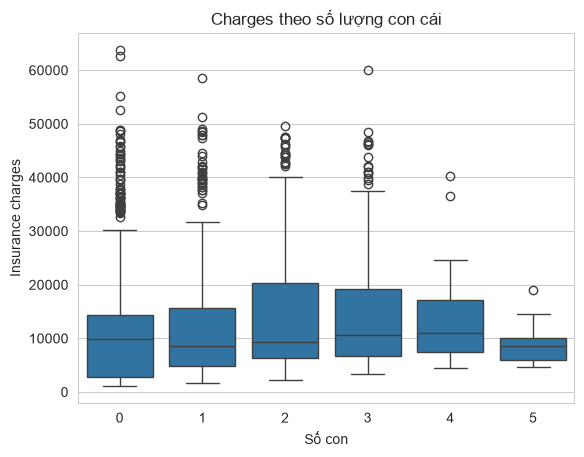

Số con có liên hệ dương nhưng rất yếu với charges; nhóm 2-3 con có mean cao nhất, còn nhóm 5 con ít quan sát nên cần diễn giải thận trọng.


In [37]:
children_summary = df.groupby('children', observed=True)['charges'].agg(['count', 'mean', 'median', 'std'])
display(children_summary.round(2))

children_corr = stats.pearsonr(df['children'], df['charges'])
print(f"Pearson r = {children_corr.statistic:.3f}, p-value = {children_corr.pvalue:.4g}")
sns.boxplot(data=df, x='children', y='charges')
plt.title('Charges theo số lượng con cái')
plt.xlabel('Số con')
plt.ylabel('Insurance charges')
plt.show()
print('Số con có liên hệ dương nhưng rất yếu với charges; nhóm 2-3 con có mean cao nhất, '
      'còn nhóm 5 con ít quan sát nên cần diễn giải thận trọng.')

## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

Pearson r = 0.299, p-value = 4.887e-29
Spearman rho = 0.534


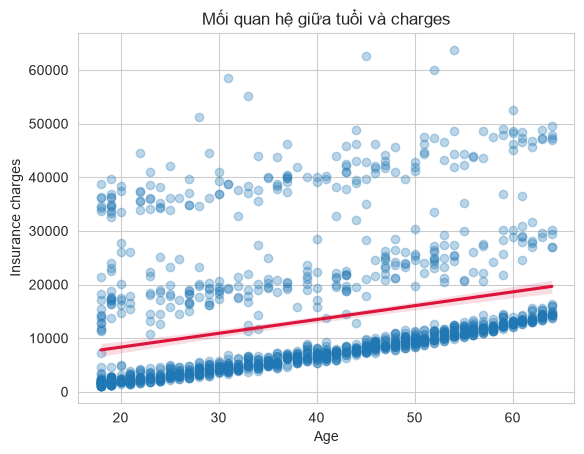

Tuổi có tương quan dương với charges; mức độ liên hệ được đánh giá qua |Pearson r|.


In [38]:
age_corr = stats.pearsonr(df['age'], df['charges'])
print(f"Pearson r = {age_corr.statistic:.3f}, p-value = {age_corr.pvalue:.4g}")
print('Spearman rho =', round(stats.spearmanr(df['age'], df['charges']).statistic, 3))

sns.regplot(data=df, x='age', y='charges', scatter_kws={'alpha': 0.3}, line_kws={'color': 'crimson'})
plt.title('Mối quan hệ giữa tuổi và charges')
plt.xlabel('Age')
plt.ylabel('Insurance charges')
plt.show()
print('Tuổi có tương quan dương với charges; mức độ liên hệ được đánh giá qua |Pearson r|.')

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

- Dữ liệu gồm 1.338 bản ghi và 7 biến ban đầu; không có giá trị thiếu hoặc giá trị số không hợp lệ, nhưng có 1 dòng trùng cần lưu ý khi xây dựng mô hình.
- Chi phí bảo hiểm (`charges`) lệch phải rõ rệt: phần lớn khách hàng có chi phí thấp hơn mức trung bình, trong khi một số ít có chi phí rất cao.
- Người hút thuốc có chi phí trung bình cao hơn nhiều lần người không hút thuốc; chênh lệch này xuất hiện ở cả bốn vùng, vì vậy hút thuốc là yếu tố phân nhóm nổi bật nhất.
- BMI liên hệ với chi phí mạnh hơn ở nhóm hút thuốc, còn tuổi có tương quan dương với chi phí; số con và vùng có ảnh hưởng nhỏ hơn khi chỉ so sánh trung bình.
- Nhóm `Obese` chiếm tỷ trọng lớn nhất trong dữ liệu, nhưng không nên diễn giải đây là quan hệ nhân quả chỉ từ các thống kê mô tả.